In [54]:
# !pip install roboflow
# !pip install ultralytics

from roboflow import Roboflow
rf = Roboflow(api_key="JI65XH6LIWNADPV84kVn")
project = rf.workspace("cricket-jjknd").project("cricket-oftm6")
version = project.version(3)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [49]:
from ultralytics import YOLO
import shutil
import random
from pathlib import Path
import matplotlib.pylab as plt
from PIL import Image
import cv2
import numpy as np

In [29]:
BASE_PATH=Path.cwd()/"cricket-3"
TRAIN_IMAGES=BASE_PATH/"train"/"images"
TRAIN_LABELS=BASE_PATH/"train"/"labels"
TEST_IMAGES=BASE_PATH/"test"/"images"
TEST_LABELS=BASE_PATH/"test"/"labels"
VALID_IMAGES=BASE_PATH/"valid"/"images"
VALID_LABELSS=BASE_PATH/"valid"/"labels"

YAML=BASE_PATH/"data.yaml"
SAVE_DIR=BASE_PATH/"models"
SAVE_DIR.mkdir(exist_ok=True,parents=True)

In [11]:
train_images=list(TRAIN_IMAGES.rglob("*.jpg"))
test_images=list(TEST_IMAGES.rglob("*.jpg"))
print("The lenght of train images is:",len(train_images))
print("The lenght of test images is:",len(test_images))

The lenght of train images is: 1847
The lenght of test images is: 225


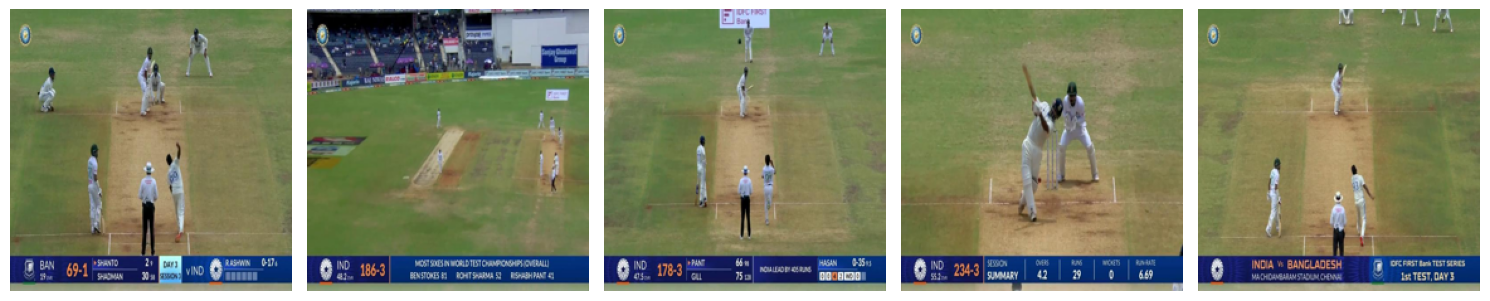

In [16]:
fig,axes=plt.subplots(1,5,figsize=(15,6))

for img in range(5):
  image=random.choice(train_images)
  image=Image.open(image).convert("RGB").resize((224,224))

  axes[img].imshow(image)
  axes[img].axis('off')

plt.tight_layout()
plt.show()

In [20]:
train_label=[label for label in TRAIN_LABELS.iterdir() if label.suffix==".txt"]
print(len(train_label))

1847


In [25]:
for label in range(5):
  new_label=train_label[label]
  with open(new_label,'r') as f:
    data=f.read().splitlines()
  print(data)
  print("*"*100)

['3 0.54921875 0.66171875 0.0671875 0.30390625', '4 0.66328125 0.465625 0.0515625 0.21640625', '4 0.390625 0.68203125 0.06953125 0.35859375', '2 0.54140625 0.48359375 0.0484375 0.14453125', '6 0.6296875 0.340625 0.04453125 0.2015625']
****************************************************************************************************
['3 0.61015625 0.66328125 0.1015625 0.33203125', '5 0.50390625 0.71171875 0.08125 0.32109375', '6 0.53671875 0.26171875 0.0671875 0.159375', '2 0.5 0.25703125 0.08203125 0.25546875', '4 0.375 0.65234375 0.08125 0.3375', '1 0.6015625 0.359375 0.01171875 0.0234375']
****************************************************************************************************
['4 0.178125 0.76328125 0.09609375 0.21796875', '6 0.5390625 0.40546875 0.0734375 0.221875', '3 0.65703125 0.78515625 0.1046875 0.1734375', '2 0.50703125 0.42578125 0.1203125 0.29609375', '1 0.5625 0.54140625 0.01328125 0.028125']
*******************************************************************

In [30]:
model=YOLO("yolov8n.pt")

result=model.train(
    data=YAML,
    epochs=5,
    imgsz=640,
    batch=16,
    device=0
)

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cricket-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

In [37]:
TRAIN_DIR = Path.cwd()/"runs"/"detect"/"train2"/"weights"

best_model_path = TRAIN_DIR / "best.pt"
last_model_path = TRAIN_DIR / "last.pt"

shutil.copy(best_model_path, SAVE_DIR/"best.pt")
shutil.copy(last_model_path, SAVE_DIR/"last.pt")

print("The files copied to:",SAVE_DIR)

The files copied to: /content/cricket-3/models


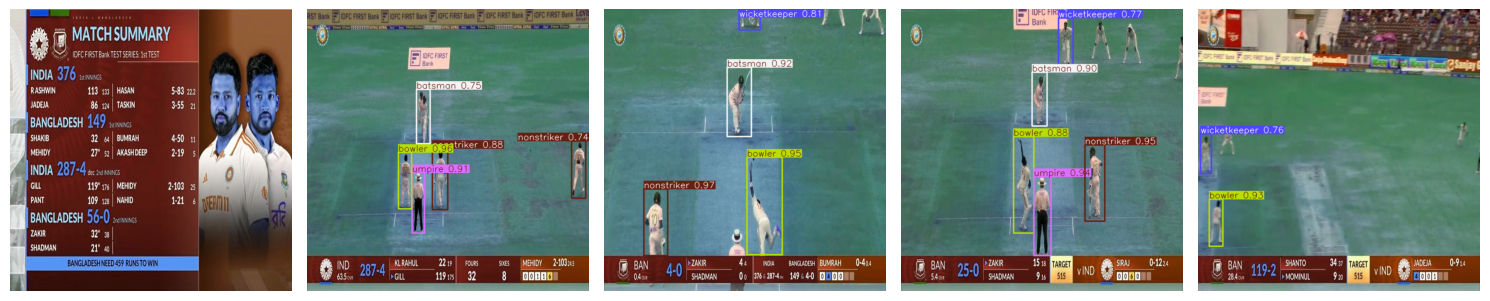

In [45]:
fig,axes=plt.subplots(1,5,figsize=(15,6))
model = YOLO(str(BASE_PATH / "models" / "best.pt"))

for img in range(5):
  image=random.choice(test_images)
  image=Image.open(image).convert("RGB").resize((640,640))

  output=model.predict(image,conf=0.5,verbose=False)
  annotated_image=output[0].plot()

  axes[img].imshow(annotated_image)
  axes[img].axis("off")
plt.tight_layout()
plt.show()

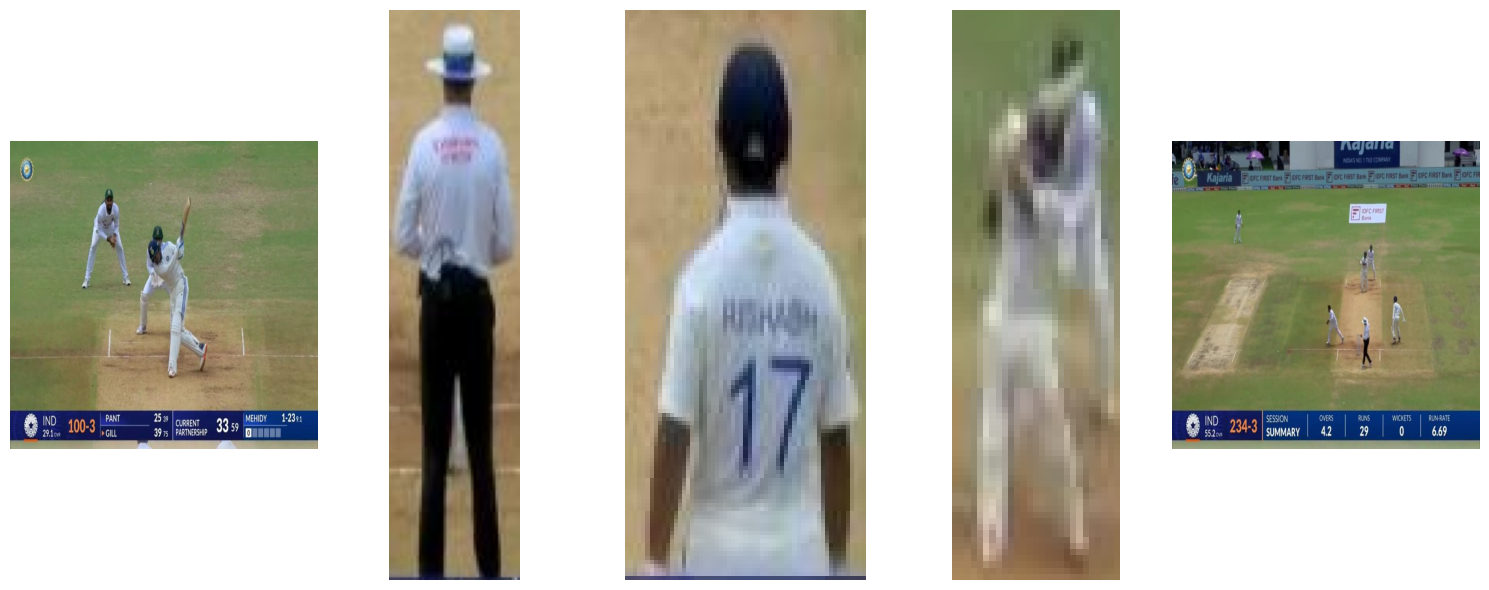

In [53]:
import cv2
fig,axes=plt.subplots(1,5,figsize=(15,6))

for img in range(5):
  image=random.choice(test_images)
  image=Image.open(image).convert("RGB")
  image_np = np.array(image)

  outputs=model.predict(image_np,conf=0.5,verbose=False)
  output=outputs[0]

  if output.boxes is not None and len(output.boxes)>0:
    x1,y1,x2,y2=output.boxes.xyxy[0].cpu().int().tolist()

    cropped_image=image_np[y1:y2,x1:x2]

    axes[img].imshow(cropped_image)
    axes[img].axis("off")
  else:
    axes[img].imshow(image_np)
    axes[img].axis("off")

plt.tight_layout()
plt.show()